<a href="https://colab.research.google.com/github/Thanuja5/cars/blob/main/Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.8/350.9 MB 4.2 MB/s eta 0:01:24
   ---------------------------------------- 1.3/350.9 MB 3.2 MB/s eta 0:01:50
   ---------------------------------------- 2.9/350.9 MB 4.8 MB/s eta 0:01:13
   ---------------------------------------- 4.2/350.9 MB 5.7 MB/

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [4]:
# ============================================
# STEP 2: Dataset Setup and Verification
# ============================================

import os

# Dataset path
data_path = "../data/flowers"

# Check whether dataset exists
if not os.path.exists(data_path):
    print("❌ Dataset path not found:", data_path)
else:
    print("✅ Dataset found:", data_path)

    # Get flower classes
    classes = sorted([
        folder for folder in os.listdir(data_path)
        if os.path.isdir(os.path.join(data_path, folder))
    ])

    print("\nFlower Classes:")
    for i, class_name in enumerate(classes, start=1):
        print(f"{i}. {class_name}")

    print("\nNumber of classes:", len(classes))

    # Count images in each class
    print("\nImages per class:")

    total_images = 0

    for class_name in classes:
        class_path = os.path.join(data_path, class_name)

        image_count = len([
            file for file in os.listdir(class_path)
            if file.lower().endswith((
                ".jpg", ".jpeg", ".png", ".bmp", ".gif"
            ))
        ])

        print(f"{class_name}: {image_count}")

        total_images += image_count

    print("\nTotal images:", total_images)

✅ Dataset found: ../data/flowers

Flower Classes:
1. daisy
2. dandelion
3. rose
4. sunflower
5. tulip

Number of classes: 5

Images per class:
daisy: 764
dandelion: 1052
rose: 784
sunflower: 733
tulip: 984

Total images: 4317


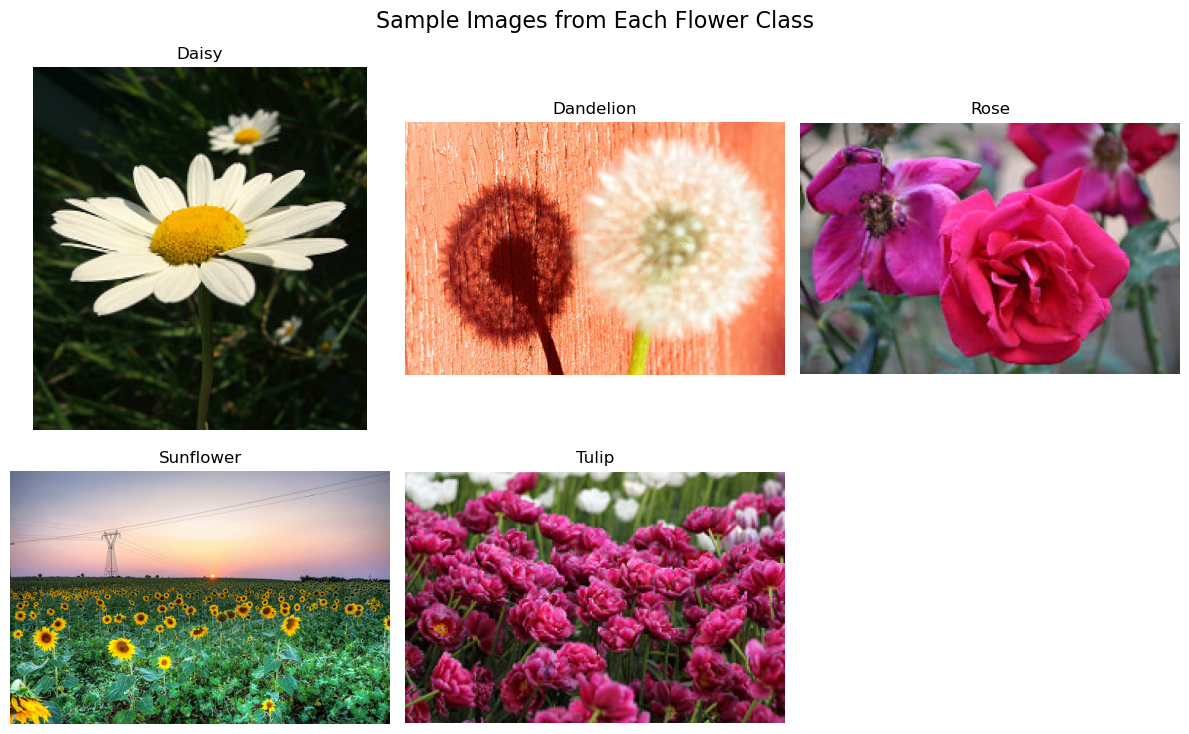

In [6]:
# ============================================
# STEP 3: Display Different Sample Images
# ============================================

import random
from PIL import Image

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(data_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    # Select a random image from the class
    image_file = random.choice(image_files)

    image_path = os.path.join(class_path, image_file)
    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name.capitalize())
    plt.axis("off")

plt.suptitle("Sample Images from Each Flower Class", fontsize=16)
plt.tight_layout()
plt.show()

Class Distribution:
daisy: 764
dandelion: 1052
rose: 784
sunflower: 733
tulip: 984


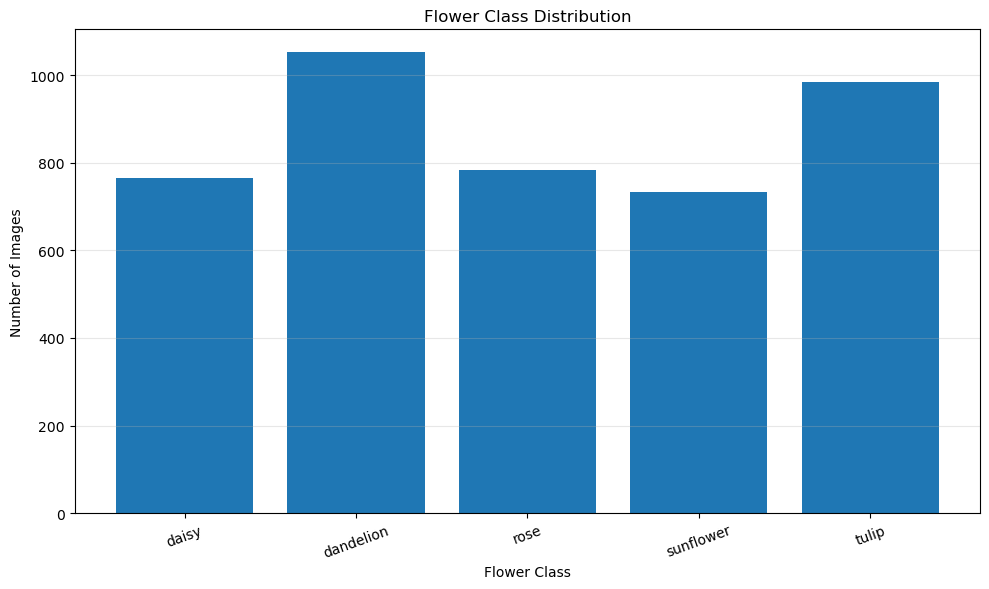

In [7]:
# ============================================
# STEP 4: Class Distribution
# ============================================

class_counts = {}

for class_name in classes:
    class_path = os.path.join(data_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    class_counts[class_name] = len(image_files)

# Print counts
print("Class Distribution:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

# Create bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.title("Flower Class Distribution")
plt.xlabel("Flower Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Save graph
os.makedirs("../images", exist_ok=True)
plt.savefig("../images/class_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [8]:
# ============================================
# STEP 5: Image Preprocessing & Data Generators
# ============================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image settings
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Training data augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    data_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

# Validation generator
validation_generator = train_datagen.flow_from_directory(
    data_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

print("\nClass indices:")
print(train_generator.class_indices)

print("\nTraining images:", train_generator.samples)
print("Validation images:", validation_generator.samples)

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.

Class indices:
{'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}

Training images: 3457
Validation images: 860


In [11]:
# ============================================
# STEP 7A: Improved CNN Model
# ============================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

improved_model = Sequential([
    
    Input(shape=(150, 150, 3)),

    # Block 1
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 2
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 3
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 4
    Conv2D(256, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Classification
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),

    Dense(5, activation="softmax")
])

improved_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     5,308,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,700,293 (21.74 MB)

 Trainable params: 5,699,333 (21.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [12]:
# ============================================
# STEP 7B: Train Improved CNN
# ============================================

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_improved = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history_improved = improved_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=25,
    callbacks=[early_stopping_improved]
)

Epoch 1/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 72s 641ms/step - accuracy: 0.3648 - loss: 3.5545 - val_accuracy: 0.2442 - val_loss: 2.8963
Epoch 2/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 71s 651ms/step - accuracy: 0.3975 - loss: 1.4755 - val_accuracy: 0.2442 - val_loss: 7.7190
Epoch 3/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 76s 700ms/step - accuracy: 0.4093 - loss: 1.4064 - val_accuracy: 0.2698 - val_loss: 2.4219
Epoch 4/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 84s 771ms/step - accuracy: 0.4336 - loss: 1.3266 - val_accuracy: 0.3849 - val_loss: 1.4225
Epoch 5/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 83s 764ms/step - accuracy: 0.4487 - loss: 1.2805 - val_accuracy: 0.5070 - val_loss: 1.2087
Epoch 6/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 86s 785ms/step - accuracy: 0.4808 - loss: 1.2756 - val_accuracy: 0.4849 - val_loss: 1.2962
Epoch 7/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.4949 - loss: 1.2363 - val_accuracy: 0.5640 - val_loss: 1.0492
Epoch 8/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.5262 - loss: 1.139

In [13]:
# ============================================
# STEP 8: MobileNetV2 Transfer Learning
# ============================================

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(150, 150, 3)
)

# Freeze pretrained layers initially
base_model.trainable = False

# Add our flower classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(5, activation="softmax")(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=output
)

# Compile
mobilenet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

C:\Users\thanu\AppData\Local\Temp\ipykernel_24572\1755233845.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
# ============================================
# STEP 9: Train MobileNetV2
# ============================================

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_mobilenet = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=[early_stopping_mobilenet]
)

Epoch 1/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.6630 - loss: 0.8918 - val_accuracy: 0.8151 - val_loss: 0.5164
Epoch 2/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.7697 - loss: 0.6188 - val_accuracy: 0.8233 - val_loss: 0.4852
Epoch 3/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.7952 - loss: 0.5338 - val_accuracy: 0.8105 - val_loss: 0.4859
Epoch 4/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.8053 - loss: 0.5078 - val_accuracy: 0.8395 - val_loss: 0.4574
Epoch 5/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.8114 - loss: 0.5220 - val_accuracy: 0.8198 - val_loss: 0.4876
Epoch 6/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.8163 - loss: 0.4800 - val_accuracy: 0.8291 - val_loss: 0.4342
Epoch 7/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 229s 2s/step - accuracy: 0.8253 - loss: 0.4677 - val_accuracy: 0.8326 - val_loss: 0.4751
Epoch 8/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 300s 3s/step - accuracy: 0.8235 - loss: 0.4729 - val_accu

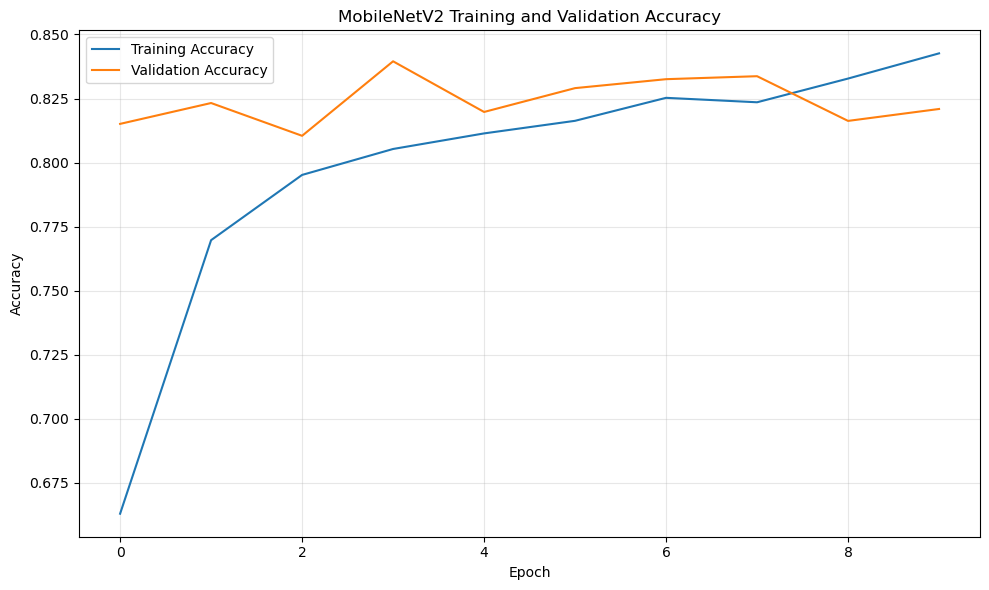

In [15]:
# ============================================
# STEP 10: MobileNetV2 Accuracy Graph
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_mobilenet.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_mobilenet.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("MobileNetV2 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../images/mobilenet_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

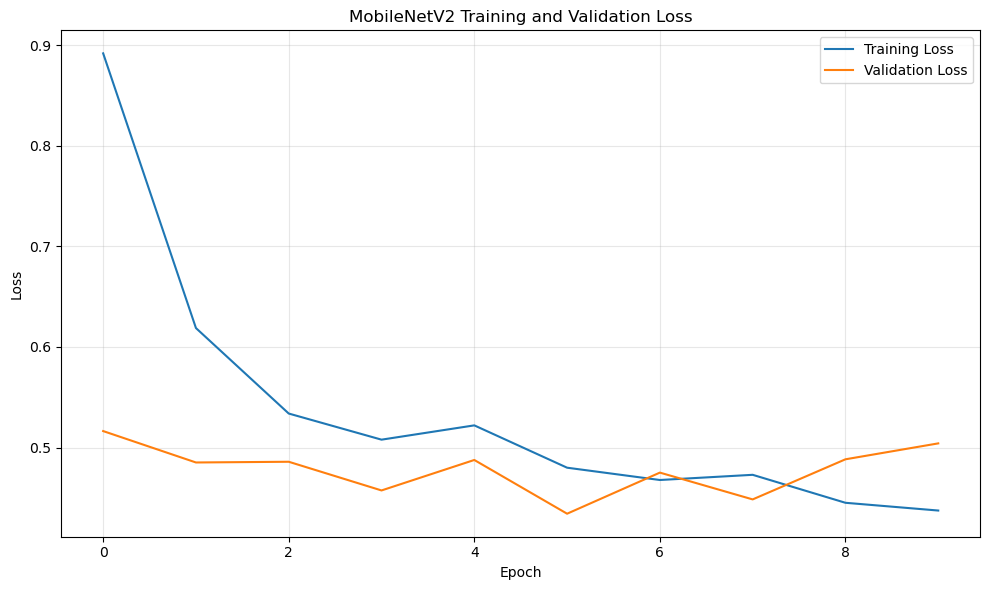

In [16]:
# ============================================
# STEP 11: MobileNetV2 Loss Graph
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_mobilenet.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_mobilenet.history["val_loss"],
    label="Validation Loss"
)

plt.title("MobileNetV2 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../images/mobilenet_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Confusion Matrix:

           daisy  dandelion  rose  sunflower  tulip
daisy        136          9     2          1      4
dandelion     14        178     2         12      4
rose           2          4   118          9     23
sunflower      2          9     3        130      2
tulip         10          1    10         11    164


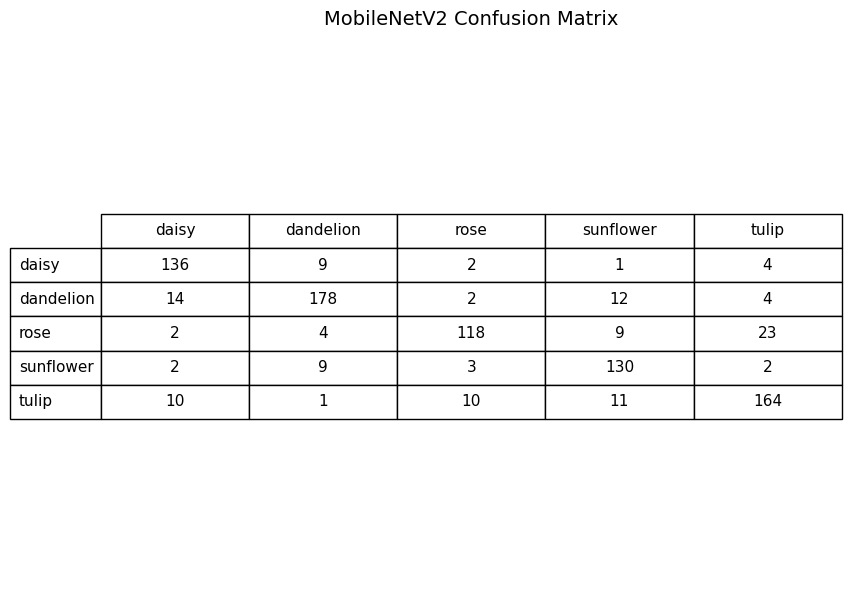


✅ Confusion matrix image saved!
📁 Location: ../images/confusion_matrix.png


In [26]:
# ============================================
# Simple Confusion Matrix - Save as PNG
# ============================================

from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

# Generate predictions
validation_generator.reset()

predictions = mobilenet_model.predict(
    validation_generator,
    verbose=0
)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

class_names = list(validation_generator.class_indices.keys())

# Create confusion matrix
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

# Print normal confusion matrix
print("Confusion Matrix:\n")

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

print(cm_df)

# Create simple table figure
fig, ax = plt.subplots(figsize=(9, 6))

ax.axis("off")

table = ax.table(
    cellText=cm,
    rowLabels=class_names,
    colLabels=class_names,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 1.8)

plt.title(
    "MobileNetV2 Confusion Matrix",
    fontsize=14,
    pad=20
)

plt.tight_layout()

# Save image
plt.savefig(
    "../images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ Confusion matrix image saved!")
print("📁 Location: ../images/confusion_matrix.png")

In [18]:
# ============================================
# STEP 13: Save Final MobileNetV2 Model
# ============================================

import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained model
model_path = "../models/flower_mobilenetv2.keras"

mobilenet_model.save(model_path)

print("✅ Model saved successfully!")
print("Model path:", model_path)

✅ Model saved successfully!
Model path: ../models/flower_mobilenetv2.keras


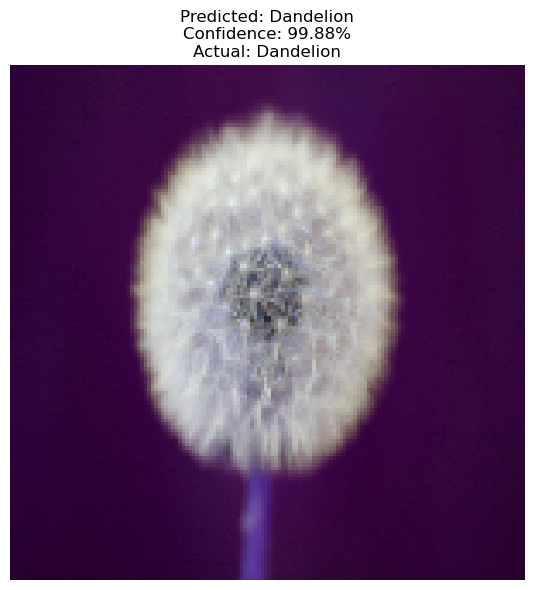

Actual class    : dandelion
Predicted class : dandelion
Confidence      : 99.88%


In [21]:
# ============================================
# STEP 14: Single Image Prediction
# ============================================

from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# Select one random image from the dataset
selected_class = random.choice(classes)

class_path = os.path.join(data_path, selected_class)

image_files = [
    file for file in os.listdir(class_path)
    if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
]

selected_image = random.choice(image_files)
image_path = os.path.join(class_path, selected_image)

# Load and preprocess image
img = image.load_img(
    image_path,
    target_size=(150, 150)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = mobilenet_model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction[0])
predicted_class = classes[predicted_index]
confidence = prediction[0][predicted_index] * 100

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(
    f"Predicted: {predicted_class.capitalize()}\n"
    f"Confidence: {confidence:.2f}%\n"
    f"Actual: {selected_class.capitalize()}"
)
plt.axis("off")
plt.tight_layout()

# Save prediction image
plt.savefig(
    "../images/sample_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Actual class    :", selected_class)
print("Predicted class :", predicted_class)
print(f"Confidence      : {confidence:.2f}%")

In [22]:
# ============================================
# STEP 15: Save Model Performance Results
# ============================================

import os
import pandas as pd

os.makedirs("../results", exist_ok=True)

# Best validation accuracy
best_val_accuracy = max(history_mobilenet.history["val_accuracy"])

# Best validation loss
best_val_loss = min(history_mobilenet.history["val_loss"])

# Final training accuracy
final_train_accuracy = history_mobilenet.history["accuracy"][-1]

results = pd.DataFrame({
    "Metric": [
        "Best Validation Accuracy",
        "Best Validation Loss",
        "Final Training Accuracy"
    ],
    "Value": [
        best_val_accuracy,
        best_val_loss,
        final_train_accuracy
    ]
})

results.to_csv(
    "../results/mobilenetv2_results.csv",
    index=False
)

print("✅ Results saved successfully!")
print(results)

✅ Results saved successfully!
                     Metric     Value
0  Best Validation Accuracy  0.839535
1      Best Validation Loss  0.434244
2   Final Training Accuracy  0.842638


In [23]:
# ============================================
# STEP 16: Model Comparison
# ============================================

comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Improved CNN",
        "MobileNetV2"
    ],
    "Validation Accuracy": [
        0.7035,
        0.60,
        best_val_accuracy
    ]
})

comparison["Validation Accuracy (%)"] = (
    comparison["Validation Accuracy"] * 100
).round(2)

comparison.to_csv(
    "../results/model_comparison.csv",
    index=False
)

print("✅ Model comparison saved!")
print(comparison)

✅ Model comparison saved!
          Model  Validation Accuracy  Validation Accuracy (%)
0  Baseline CNN             0.703500                    70.35
1  Improved CNN             0.600000                    60.00
2   MobileNetV2             0.839535                    83.95


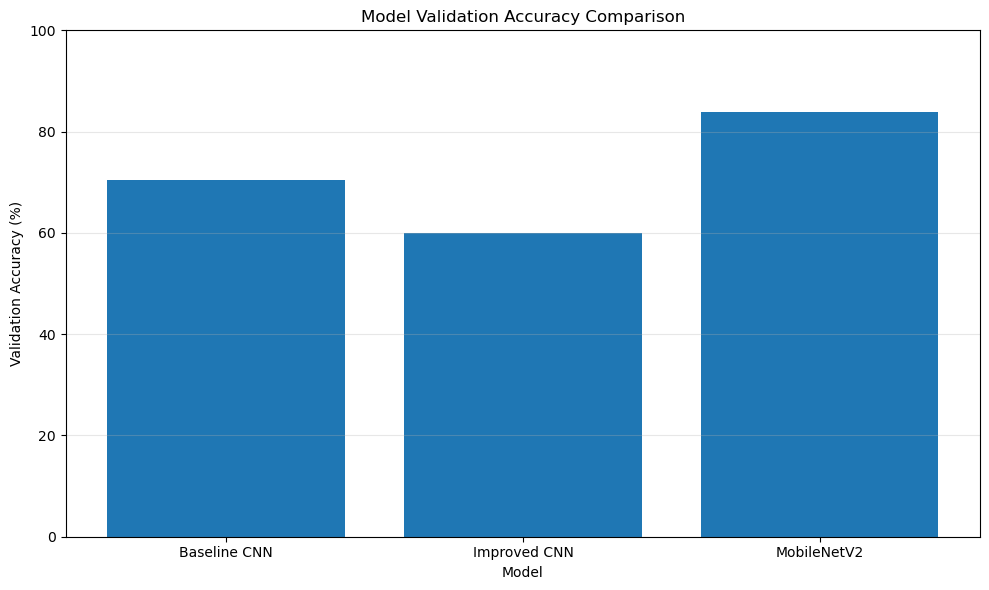

In [24]:
# ============================================
# STEP 17: Model Comparison Graph
# ============================================

plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Model"],
    comparison["Validation Accuracy (%)"]
)

plt.title("Model Validation Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Validation Accuracy (%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../images/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()